# Running STARIT on a simulated dataset

First we will read in the simulated data.

simulation_nuclear_peri_dataset.csv has columns: x_position,y_position,gene_id,cell_id,group_id

simulation_nuclear_peri_dataset_count_matrix.csv has columns: cell_id,group,gene1,gene2,gene3

NOTE: you may need to pip install a few packages ahead of time that are not default in STARIT. These packages are for downstream analysis.


In [ ]:
# here is how you can install them in a jupyter notebook
# !pip install pandas
# !pip install torchvision
# !pip install scikit-learn

Let's import our packages and read in our data.

In [1]:
# import packages
import pandas as pd
from starit import starit, save_image, get_bounding_box
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import kneighbors_graph
# import community as cl  # or community_louvain depending on your install
import community.community_louvain as cl
from sklearn.manifold import TSNE
from sklearn.metrics import jaccard_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from torchvision import transforms, models
import torch


# read in data 
sim_data_folder = "simulated_nuclear_peri"

print("Loading dataset without noise.")
dataset = pd.read_csv(f"data/{sim_data_folder}/simulation_nuclear_peri_dataset.csv")
counts_matrix = pd.read_csv(f"data/{sim_data_folder}/simulation_nuclear_peri_dataset_count_matrix.csv", index_col=0)

Loading dataset without noise.


We can print the dataset head to see what it looks like.

In [2]:
print("Dataset head:")
print(dataset.head())
print(dataset.shape)

print("\n")

print("Counts matrix head:")
print(counts_matrix.head())
print(counts_matrix.shape)

Dataset head:
   x_position  y_position gene_id  cell_id group_id
0         180         131   gene1        1   group1
1          88         129   gene1        1   group1
2         175         111   gene1        1   group1
3         125         172   gene1        1   group1
4          91         181   gene1        1   group1
(4000, 5)


Counts matrix head:
        group_id  gene1  gene2  gene3
cell_id                              
1         group1     50      0      0
2         group1     50      0      0
3         group1     50      0      0
4         group1     50      0      0
5         group1     50      0      0
(80, 4)


To ensure all STARIT images preserve the same aspect ratio as the underlying data, we first determine the largest rectangular region (bounding box) that encompasses every transcript across all cells. This bounding box defines the full spatial extent of the dataset — essentially, the outermost limits of where any transcript is located.

We then use this bounding box as the canvas or background for each image. Each cell’s transcripts are plotted at their true spatial coordinates within this shared coordinate system, ensuring that all images are aligned, scaled consistently, and visually comparable across cells or samples.

In [3]:
# get the bounding box of the dataset
bounding_box = get_bounding_box(dataset['x_position'], dataset['y_position'])
print("Bounding box [min_x, max_x, min_y, max_y]:")
print(bounding_box)

Bounding box [min_x, max_x, min_y, max_y]:
(np.float64(30.599999999999994), np.float64(194.4), np.float64(31.599999999999994), np.int64(187))


Now we are ready to make STARIT images! This code generates STARIT and placeholder images for every valid cell–gene combination within each experimental group. For each group, it identifies all cells belonging to that group and iterates over all possible genes, creating one image per combination. If transcript data exist for a given cell–gene pair, the STARIT algorithm is used to produce a spatial intensity image; if no transcripts are present, a black placeholder image is generated instead. This ensures that every group folder contains a complete and consistently structured set of images—one for every expected cell–gene pairing—regardless of missing or empty data.


Generating STARIT and placeholder images for 4 groups...

 Processing group1: 20 cells x 3 genes
0 of 50
49 of 50
STARIT result saved for group1 | cell 1, gene gene1
Placeholder saved for group1 | cell 1, gene gene2
Placeholder saved for group1 | cell 1, gene gene3
0 of 50
49 of 50
STARIT result saved for group1 | cell 2, gene gene1
Placeholder saved for group1 | cell 2, gene gene2
Placeholder saved for group1 | cell 2, gene gene3
0 of 50
49 of 50
STARIT result saved for group1 | cell 3, gene gene1
Placeholder saved for group1 | cell 3, gene gene2
Placeholder saved for group1 | cell 3, gene gene3
0 of 50
49 of 50
STARIT result saved for group1 | cell 4, gene gene1
Placeholder saved for group1 | cell 4, gene gene2
Placeholder saved for group1 | cell 4, gene gene3
0 of 50
49 of 50
STARIT result saved for group1 | cell 5, gene gene1
Placeholder saved for group1 | cell 5, gene gene2
Placeholder saved for group1 | cell 5, gene gene3
0 of 50
49 of 50
STARIT result saved for group1 | cell 6, 

/tmp/ipykernel_636462/2162478800.py:41: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(image_size[0] / 100, image_size[1] / 100), dpi=100)
/home/caleb/Desktop/STARIT/src/starit/starit.py:129: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


49 of 50
STARIT result saved for group2 | cell 22, gene gene2
Placeholder saved for group2 | cell 22, gene gene3
Placeholder saved for group2 | cell 23, gene gene1
0 of 50
49 of 50
STARIT result saved for group2 | cell 23, gene gene2
Placeholder saved for group2 | cell 23, gene gene3
Placeholder saved for group2 | cell 24, gene gene1
0 of 50
49 of 50
STARIT result saved for group2 | cell 24, gene gene2
Placeholder saved for group2 | cell 24, gene gene3
Placeholder saved for group2 | cell 25, gene gene1
0 of 50
49 of 50
STARIT result saved for group2 | cell 25, gene gene2
Placeholder saved for group2 | cell 25, gene gene3
Placeholder saved for group2 | cell 26, gene gene1
0 of 50
49 of 50
STARIT result saved for group2 | cell 26, gene gene2
Placeholder saved for group2 | cell 26, gene gene3
Placeholder saved for group2 | cell 27, gene gene1
0 of 50
49 of 50
STARIT result saved for group2 | cell 27, gene gene2
Placeholder saved for group2 | cell 27, gene gene3
Placeholder saved for group

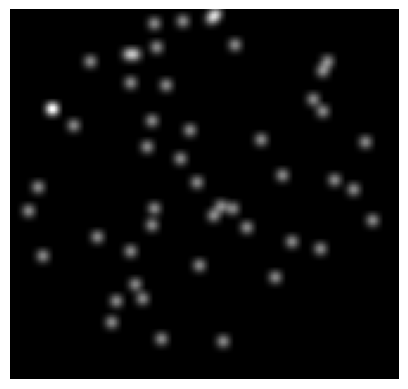

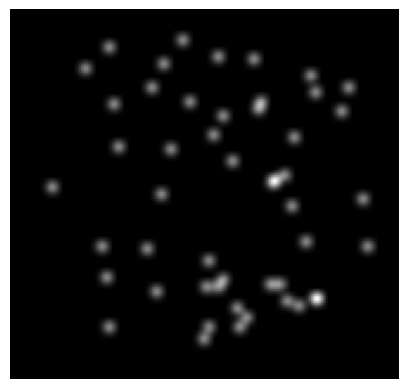

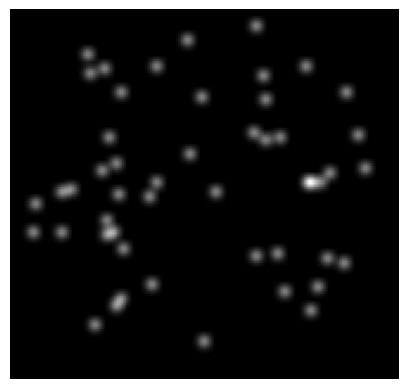

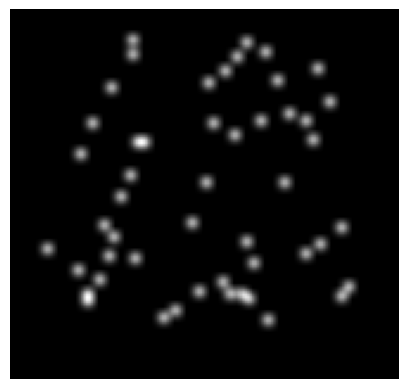

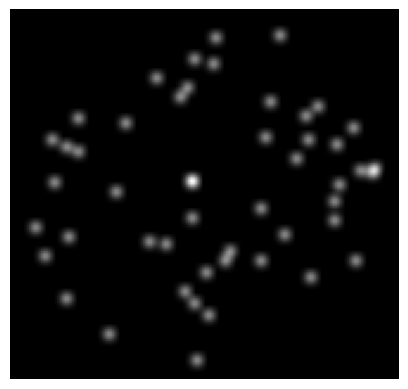

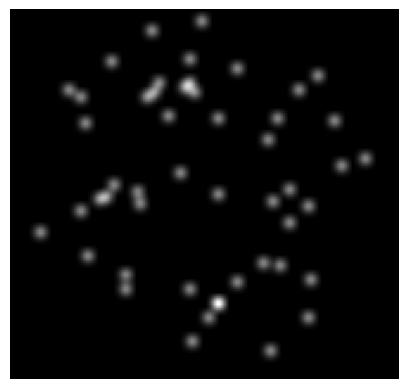

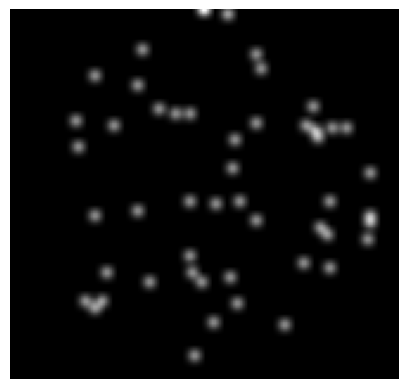

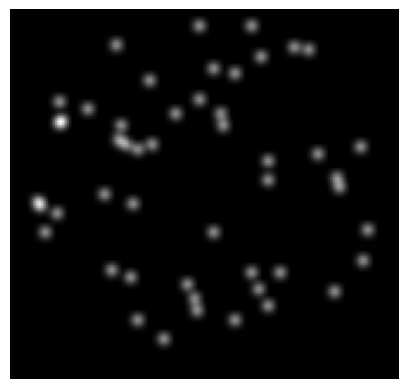

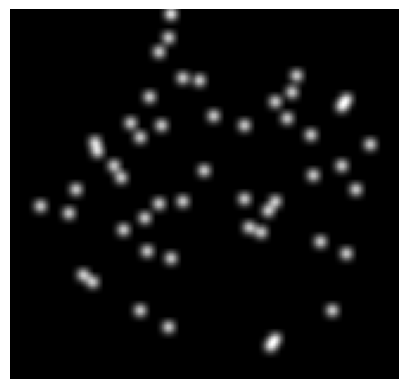

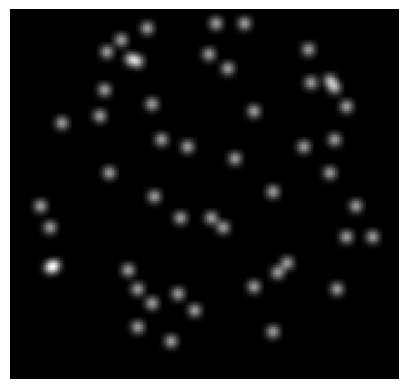

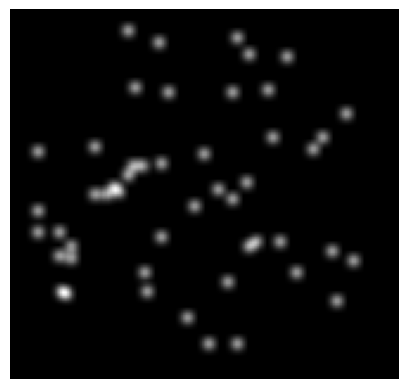

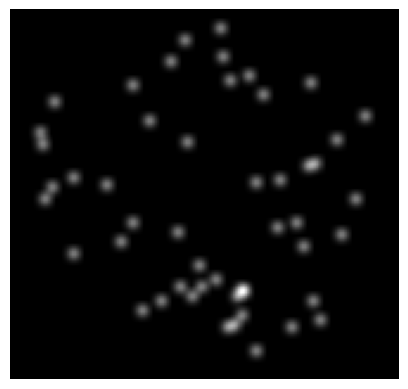

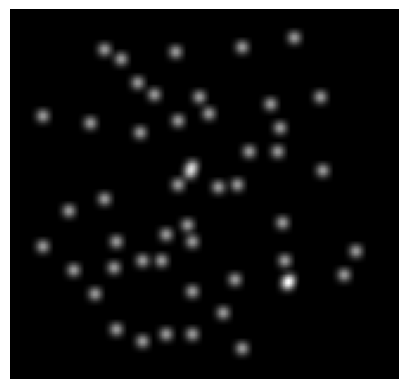

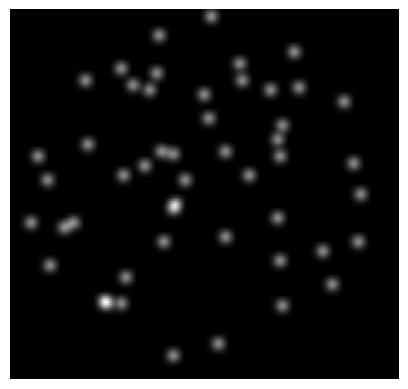

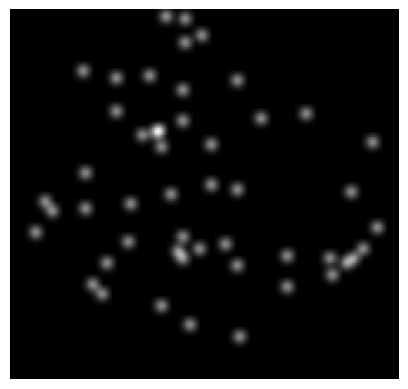

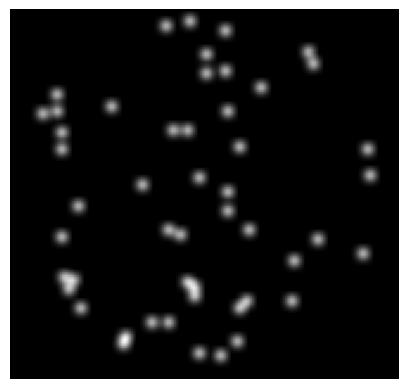

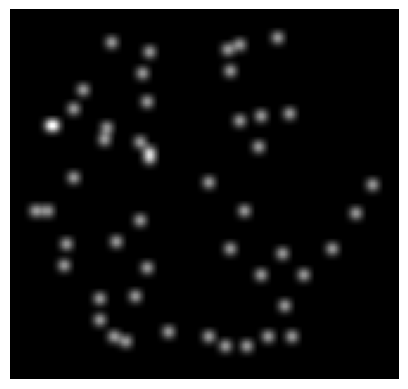

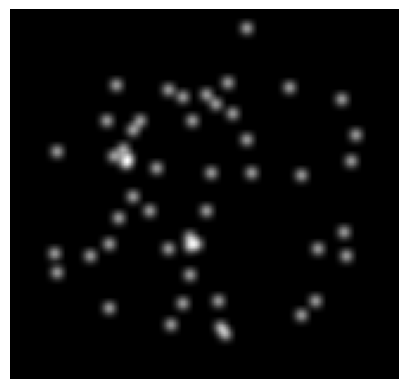

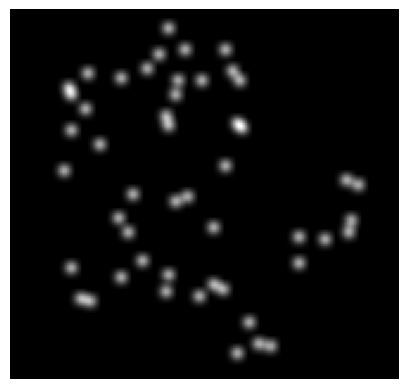

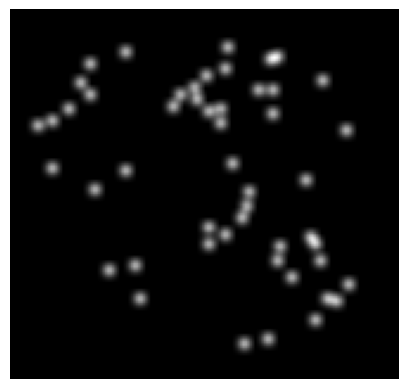

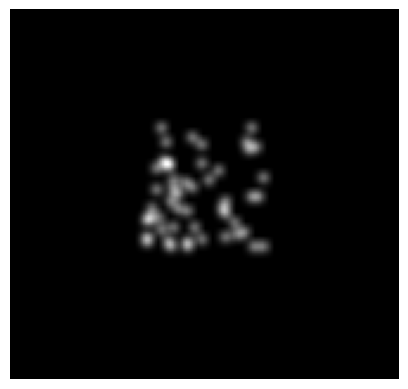

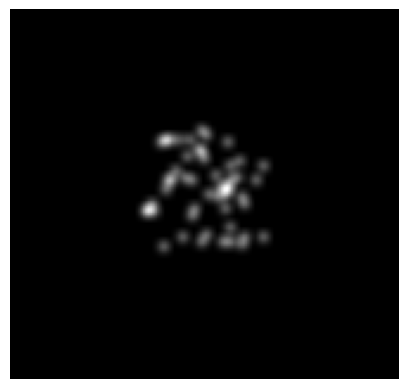

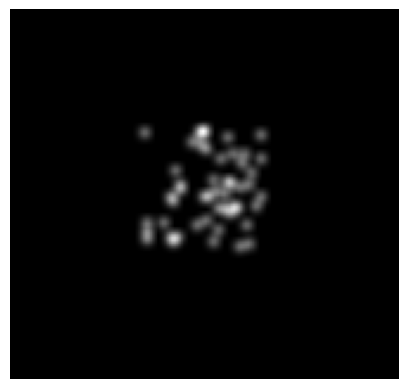

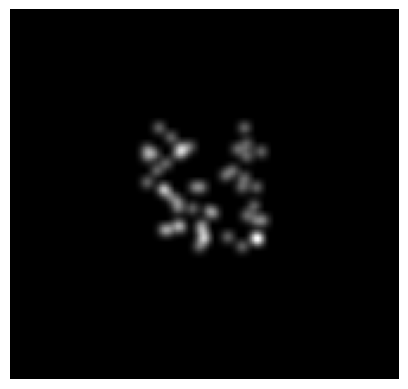

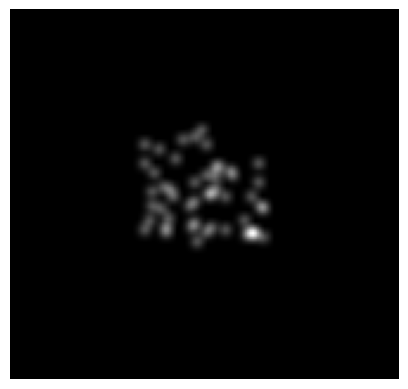

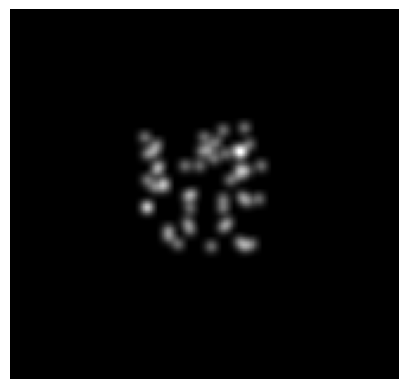

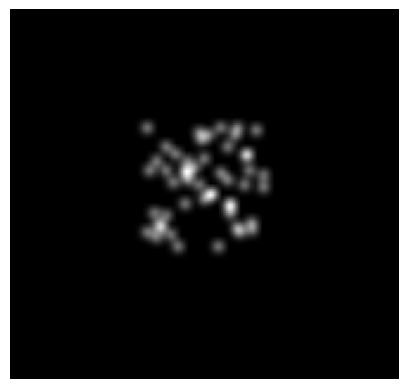

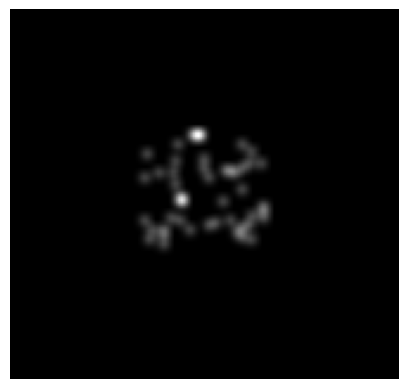

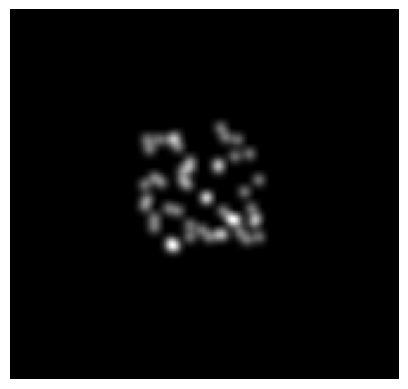

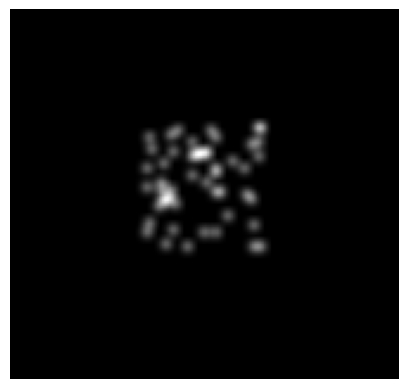

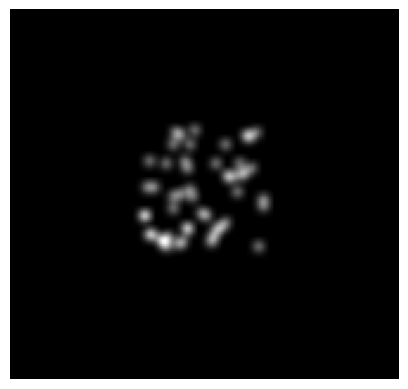

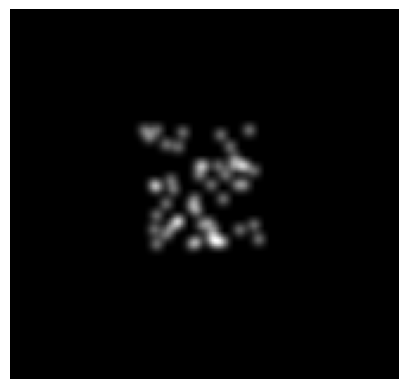

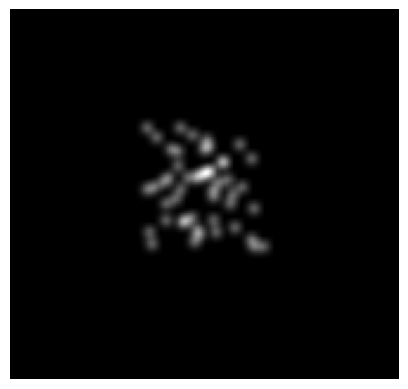

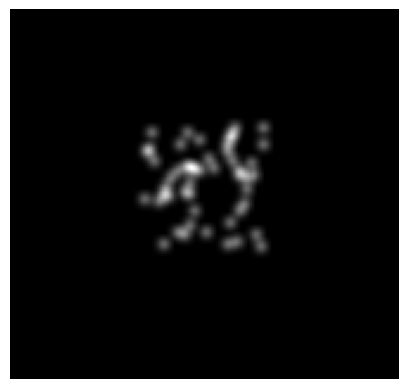

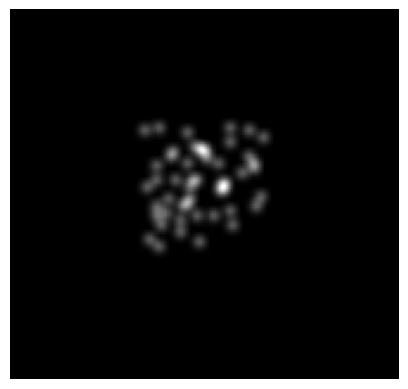

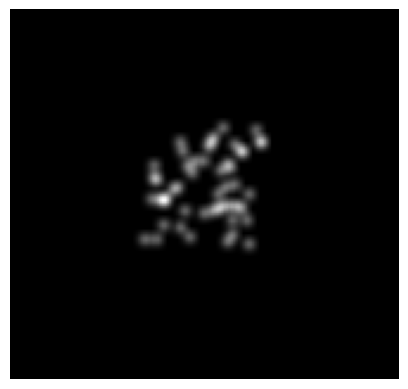

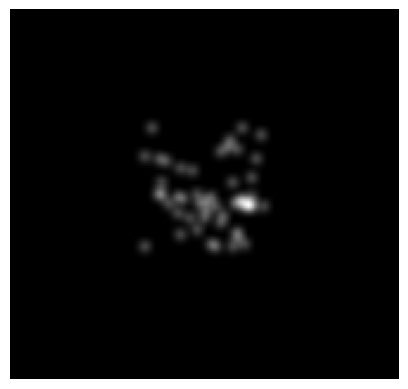

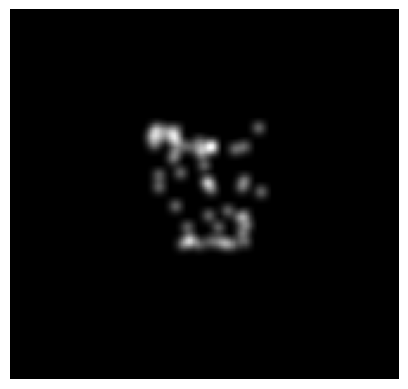

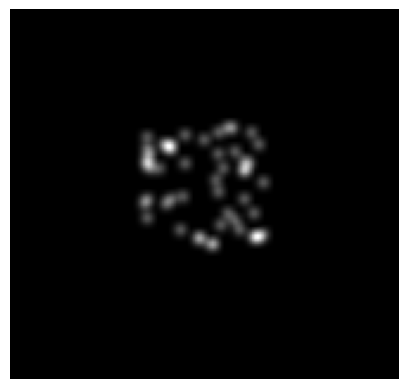

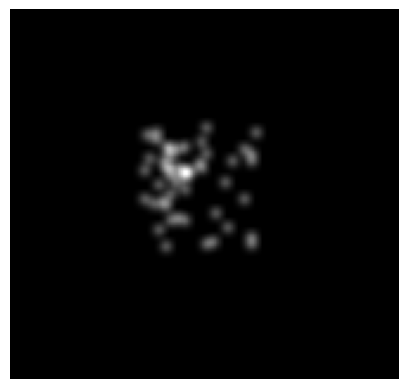

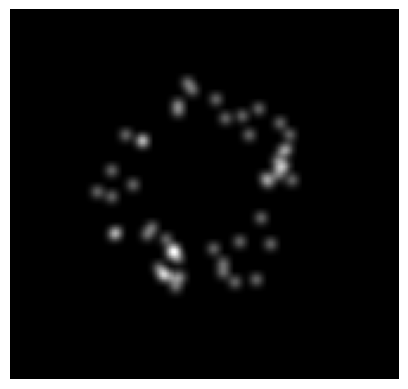

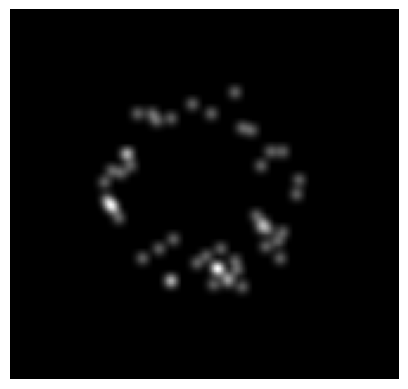

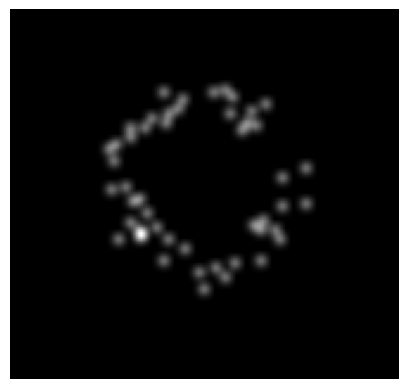

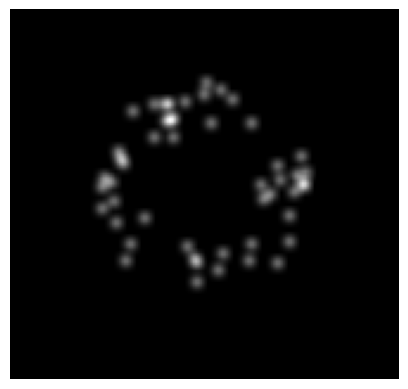

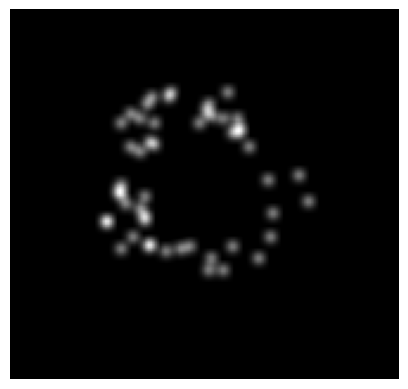

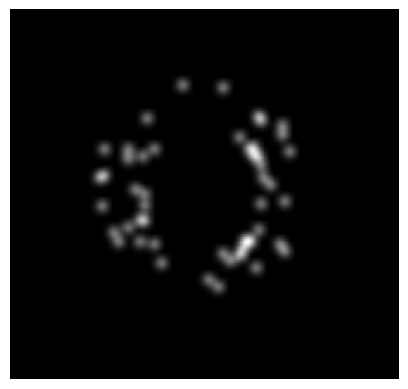

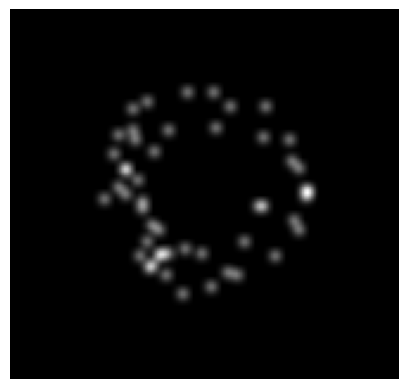

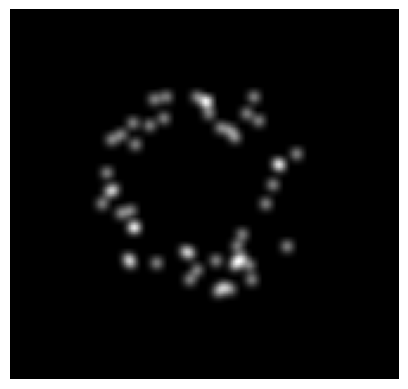

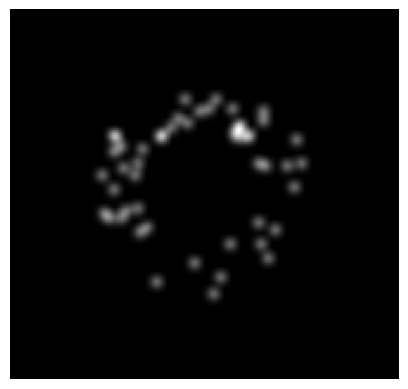

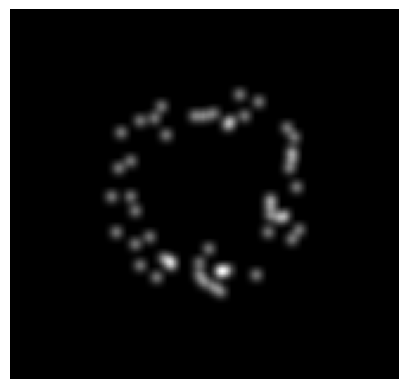

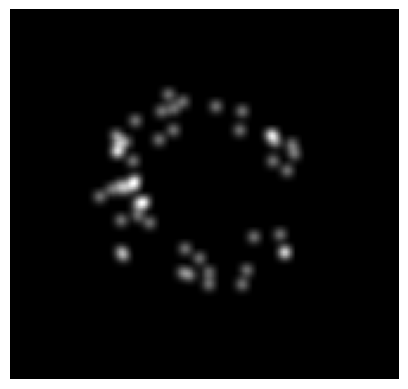

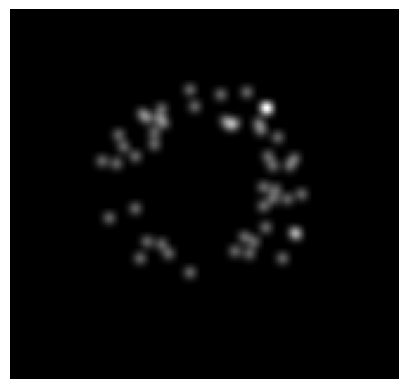

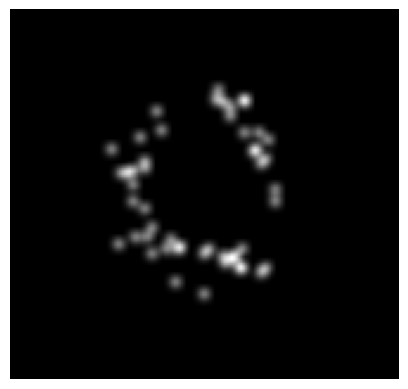

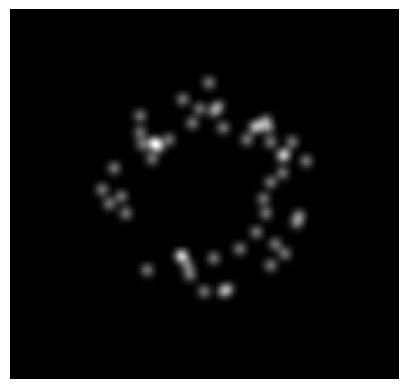

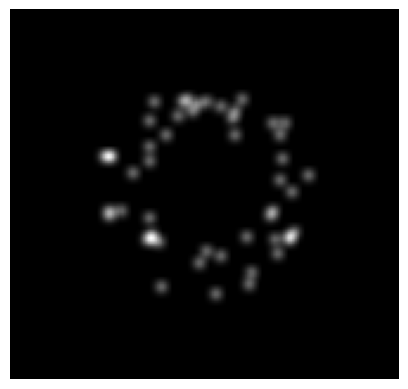

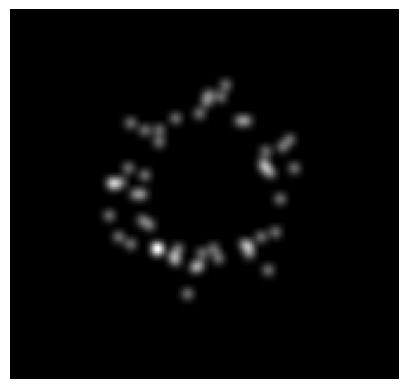

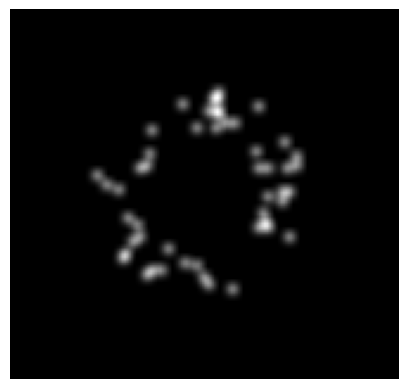

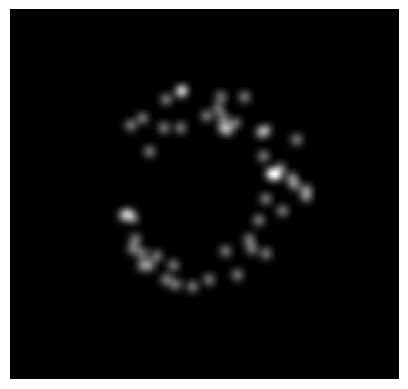

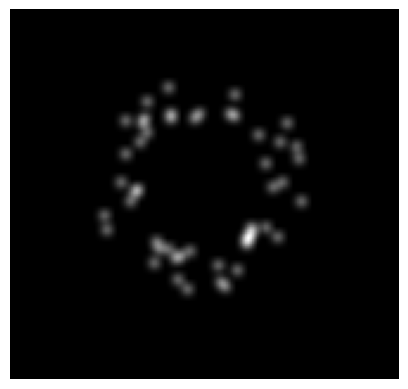

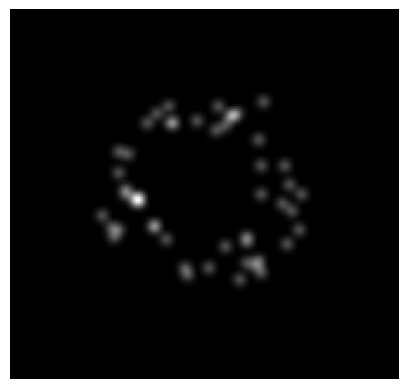

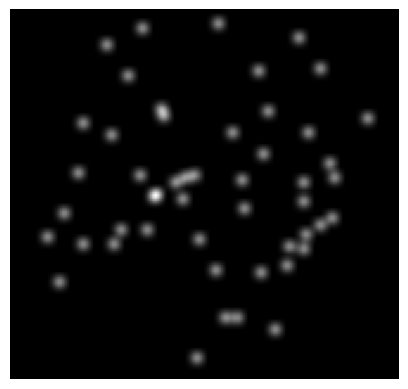

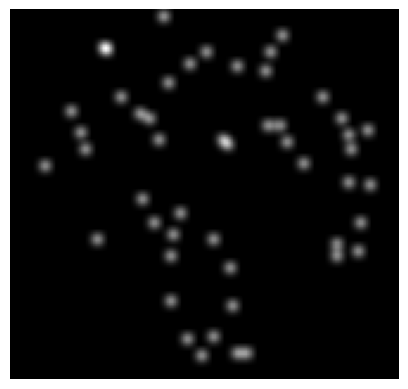

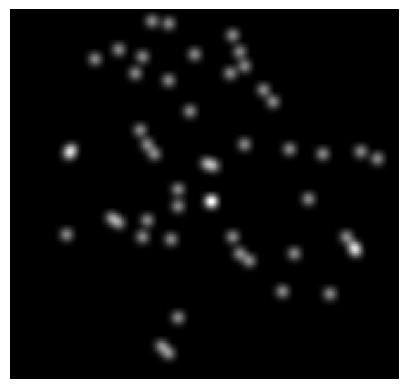

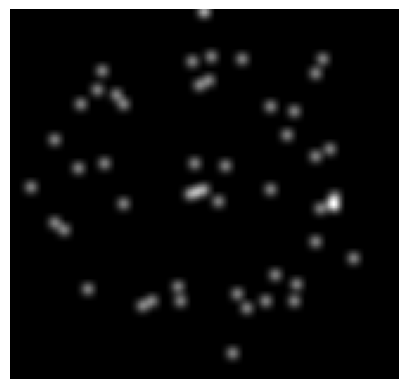

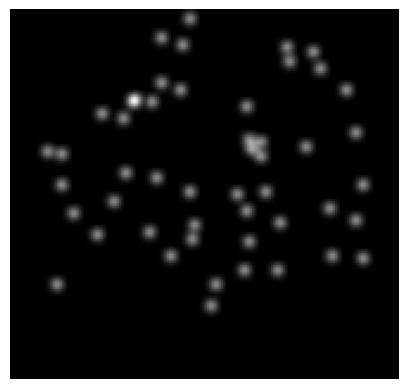

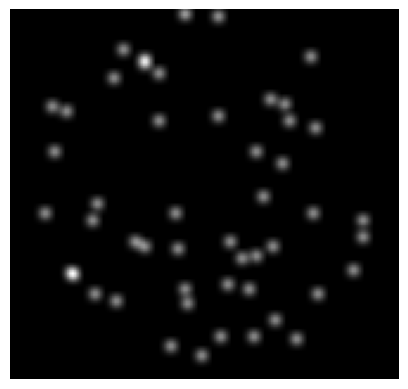

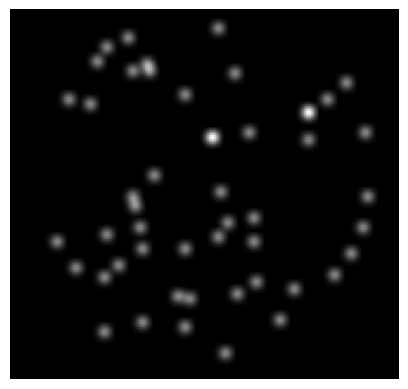

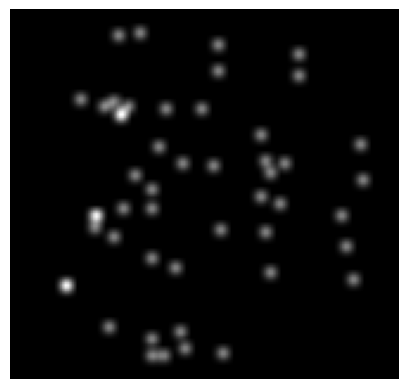

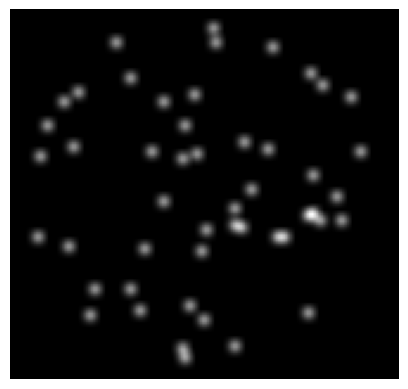

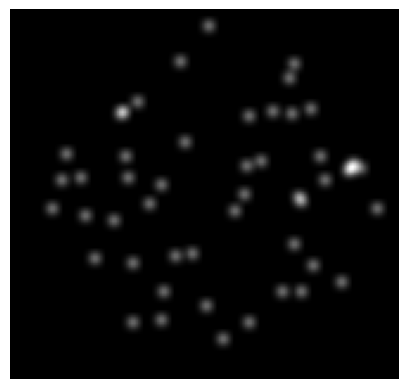

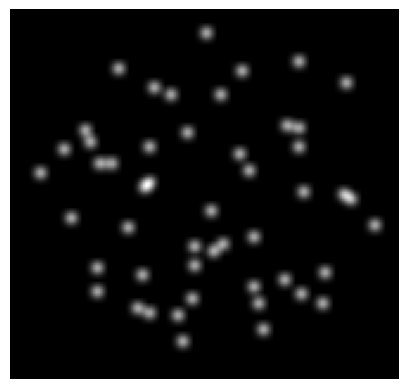

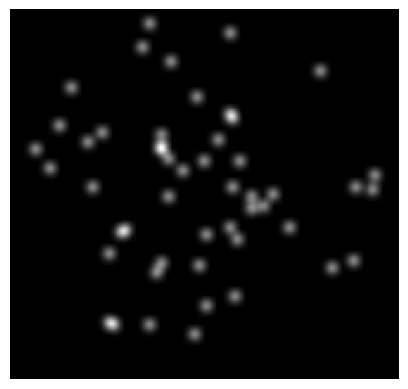

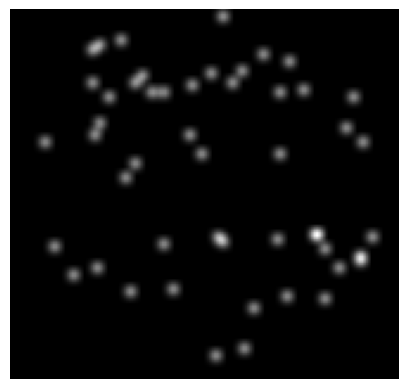

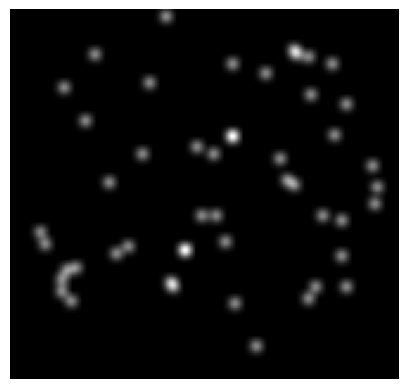

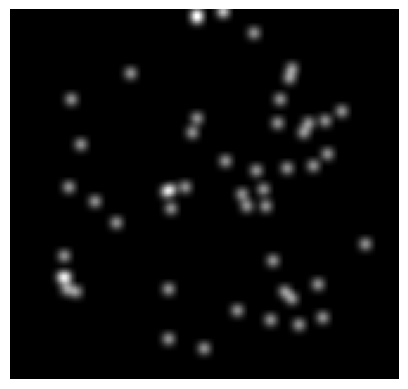

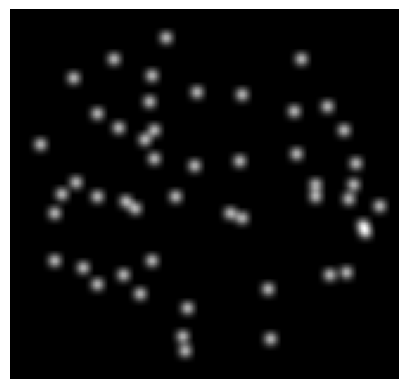

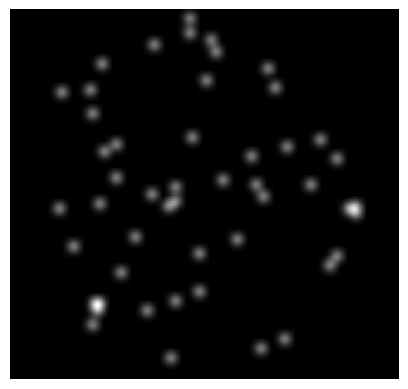

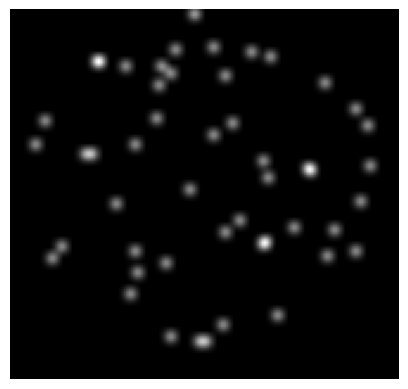

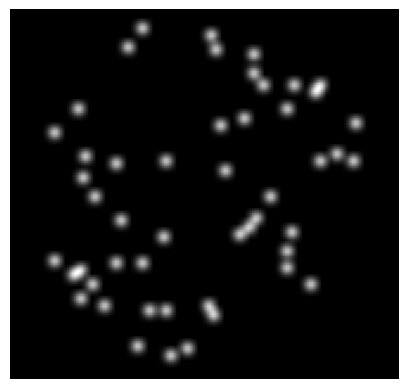

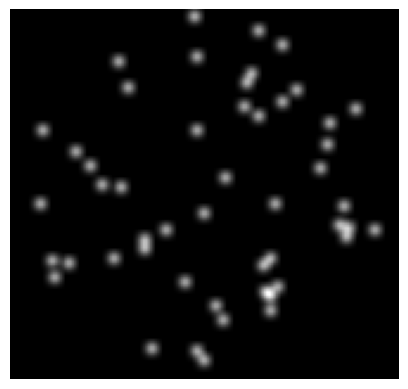

In [ ]:
# Extract unique groups
group_list = sorted(dataset["group_id"].dropna().unique().tolist())

# Define image size - use this bc resnet expects 224x224 images
image_size = (224, 224)

# Track how many images were generated per group
group_counts = {}

print(f"Generating STARIT and placeholder images for {len(group_list)} groups...")

# iteratreate through each group
for group_id in group_list:
    # Subset dataset for this group
    group_data = dataset[dataset["group_id"] == group_id]
    group_dir = f"data/{sim_data_folder}/{group_id}"
    os.makedirs(group_dir, exist_ok=True)

    # Identify all cells and genes for this group
    group_cells = group_data["cell_id"].unique()
    group_genes = dataset["gene_id"].unique()  # All possible genes across dataset
    total_images = 0

    print(f"\n Processing {group_id}: {len(group_cells)} cells x {len(group_genes)} genes")

    # Iterate through each cell and gene combination
    for cell_id in group_cells:
        for gene_id in group_genes:
            # Subset for current group, cell, and gene
            subset_data = group_data[
                (group_data["cell_id"] == cell_id) & 
                (group_data["gene_id"] == gene_id)
            ]

            # Define save path
            save_path = os.path.join(group_dir, f"cell_{cell_id}_{gene_id}_starit_result.png")

            # if no data points for this cell and gene, create black placeholder
            if subset_data.empty or subset_data["x_position"].isna().all() or subset_data["y_position"].isna().all():
                # Create a black placeholder image
                fig, ax = plt.subplots(figsize=(image_size[0] / 100, image_size[1] / 100), dpi=100)
                ax.set_xlim(0, image_size[0])
                ax.set_ylim(0, image_size[1])
                ax.set_facecolor("black")
                ax.axis("off")
                fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="black")
                plt.close(fig)
                print(f"Placeholder saved for {group_id} | cell {cell_id}, gene {gene_id}")
            else:
                # else, Run STARIT
                results = starit(
                    bounding_box,
                    subset_data["x_position"],
                    subset_data["y_position"],
                    dx=1.0,
                    blur=1.0,
                    draw=10000,
                    wavelet_magnitude=False,
                    use_windowing=True
                )
                save_image(results[2], save_path)
                print(f"STARIT result saved for {group_id} | cell {cell_id}, gene {gene_id}")

            total_images += 1

    group_counts[group_id] = total_images
    print(f"Finished {group_id}: {total_images} total images generated.")

print("\n All groups processed successfully.")
print("Summary of images per group:", group_counts)


This code sets up a pipeline to extract deep image features using a pretrained ResNet-101 model. It first defines a preprocessing transform that resizes images to 224×224px (which is why we made 224x224px black images if we had no genes for that cell), converts them to tensors, and normalizes pixel values according to ResNet’s training parameters. The final fully connected layer of ResNet-101 is replaced with an identity layer so the network outputs raw feature embeddings instead of classification scores. The extract_features() function loads an image, applies the transform, and passes it through the model in inference mode to return its feature vector. The calculate_jaccard_similarity() will calculate the jaccard similarity between our cluster annotations and ground truth, this is used later on in the notebook. Lastly, the sort_key() function provides a way to sort image file paths by their embedded cell and gene IDs, ensuring consistent ordering when processing multiple images.

In [5]:
# Convert image to tensor and normalize as required by ResNet50
transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

# Load the pre-trained ResNet101 model
resnet101 = models.resnet101(pretrained=True)
resnet101.fc = torch.nn.Identity()

# extract features from images using a model
def extract_features(image_path, model):
    # read in image
    img = Image.open(image_path).convert('RGB')
    # Prepare image for model using the modified transform
    input_tensor = transform(img)
    input_batch = input_tensor.unsqueeze(0) # Create a mini-batch as expected by the model

    # Get the feature vector and extract features
    with torch.no_grad():
        features = model(input_batch)

    return features


# calculate jaccard similarity between clusters and annotations
def calculate_jaccard_similarity(cluster_labels, annotations):
    # Encode labels as integers
    le = LabelEncoder()
    cluster_labels_encoded = le.fit_transform(cluster_labels)
    label1 = le.classes_
    annotations_encoded = le.fit_transform(annotations)
    label2 = le.classes_

    # Calculate Jaccard similarity matrix
    n_label1 = len(label1)
    n_label2 = len(label2)
    jaccard_matrix = np.zeros((n_label1, n_label2))

    for i in range(n_label1):
        for j in range(n_label2):
            jaccard_matrix[i, j] = jaccard_score(cluster_labels_encoded == i, annotations_encoded == j)

    return jaccard_matrix, label1, label2


# Define custom sort key
def sort_key(path):
    # Extract cell and gene numbers using regex
    cell_match = re.search(r'cell_(\d+)', path)
    gene_match = re.search(r'gene(\d+)', path)
    cell_id = int(cell_match.group(1)) if cell_match else 0
    gene_id = int(gene_match.group(1)) if gene_match else 0
    return (cell_id, gene_id)

/home/caleb/anaconda3/envs/starit/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/caleb/anaconda3/envs/starit/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


This code processes simulated STARIT images to extract and combine deep learning features for each cell. It iterates through four group folders, listing and sorting all image files by their cell and gene IDs using the sort_key() function. For every three images (corresponding to three genes from the same cell), it loads each image, passes it through the pretrained ResNet-101 model to extract features, and concatenates the resulting feature vectors along the feature dimension. Each concatenated feature matrix—representing the combined information from three gene images of one cell is stored in a dictionary (data) using the cell ID as the key. This produces a structured dataset mapping each cell to its fused multi-gene feature representation.

In [6]:
# parameters for reading in data
data_folder = f"data/{sim_data_folder}/"
folders = ['group1', 'group2', 'group3', 'group4']
data = {}

# iterate through each folder
for folder in folders:
    folder_path = os.path.join(data_folder, folder)
    # initialize file list
    file_list = []
        
    if os.path.exists(folder_path):
        # List all files in the folder
        files = os.listdir(folder_path)
        
        # Add filenames to the file_list and annotations to the annotations list
        file_list.extend([os.path.join(folder_path, file) for file in files])

        # Sort the list
        file_list_sorted = sorted(file_list, key=sort_key)

    print(f"Folder: {folder}, Number of files: {len(file_list_sorted)}")

    # now want to extract features for all files in file_list
    for i in range(0, len(file_list_sorted), 3):
        # Get the current triplet (gene1, gene2, gene3)
        group_files = file_list_sorted[i:i+3]
        print(f"Processing files: {group_files}")

        # Extract features for each gene image
        feat_list = []
        for img_path in group_files:
            feat = extract_features(img_path, resnet101)
            feat_list.append(feat)

        # Concatenate features horizontally (axis=1)
        feat_concat = np.concatenate(feat_list, axis=1)

        # Extract cell ID from filename for dictionary key
        cell_match = re.search(r'cell_(\d+)', group_files[0])
        cell_id = int(cell_match.group(1)) if cell_match else i // 3

        # Store concatenated feature in dictionary
        data[cell_id] = feat_concat

Folder: group1, Number of files: 60
Processing files: ['data/simulated_nuclear_peri/group1/cell_1_gene1_starit_result.png', 'data/simulated_nuclear_peri/group1/cell_1_gene2_starit_result.png', 'data/simulated_nuclear_peri/group1/cell_1_gene3_starit_result.png']
Processing files: ['data/simulated_nuclear_peri/group1/cell_2_gene1_starit_result.png', 'data/simulated_nuclear_peri/group1/cell_2_gene2_starit_result.png', 'data/simulated_nuclear_peri/group1/cell_2_gene3_starit_result.png']
Processing files: ['data/simulated_nuclear_peri/group1/cell_3_gene1_starit_result.png', 'data/simulated_nuclear_peri/group1/cell_3_gene2_starit_result.png', 'data/simulated_nuclear_peri/group1/cell_3_gene3_starit_result.png']
Processing files: ['data/simulated_nuclear_peri/group1/cell_4_gene1_starit_result.png', 'data/simulated_nuclear_peri/group1/cell_4_gene2_starit_result.png', 'data/simulated_nuclear_peri/group1/cell_4_gene3_starit_result.png']
Processing files: ['data/simulated_nuclear_peri/group1/cell_

We want to put this data into a cell x feature matrix, so we convert the dictionary to an array and reshape it to be the correct dimensions.

In [7]:
# Convert data dictionary to numpy array
cell_features = np.array(list(data.values()))
print(cell_features.shape)
# need to reshape cell_features to (num_cells, 6144)
cell_features = cell_features.reshape(-1, 6144)
print(cell_features.shape)

(80, 1, 6144)
(80, 6144)


We will convert group labels into numerical format for visualization. It first extracts the list of group identifiers (e.g., 'group1', 'group2') from the dataset, then uses a LabelEncoder to transform these text labels into integer codes (e.g., group1 = 0, group2 = 1, etc.). The resulting numeric values (colors) can be used to color points by group in plots or to provide categorical labels for machine learning models.

In [8]:
# Create labels for each group since we know the order
labels = counts_matrix['group_id'].tolist()

# Convert text labels (like 'group1', 'group2') to numeric codes
le = LabelEncoder()
colors = le.fit_transform(labels)  # e.g. group1 -> 0, group2 -> 1, etc.

First, we apply Principal Component Analysis (PCA) to compress the features into 30 components while preserving most of the variance. The first two PCA components are plotted in a scatter plot, colored by group to reveal broad structure. Then, t-SNE (t-Distributed Stochastic Neighbor Embedding) is applied to the PCA-reduced data to capture finer, nonlinear relationships between samples. The resulting 2D embedding is plotted to visualize how cells cluster based on their learned feature similarities. We can also cluster this data using louvain clustering, and check to see how these clusters agree with the ground truth labels.

Since this dataset has no noise (extra gene counts), we see distinct clusters in the tSNE plot. Here, there is no need for feature weighting but we show it just for reference.

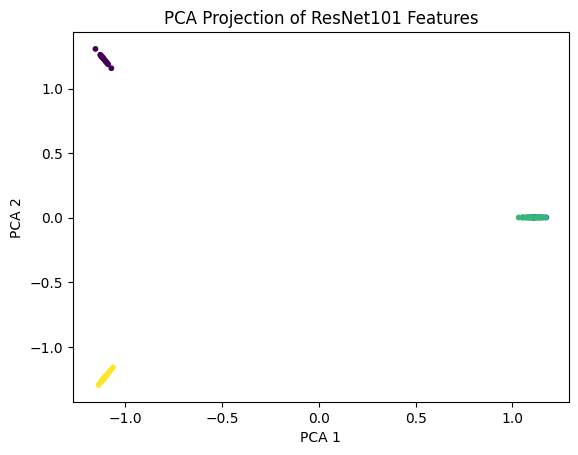

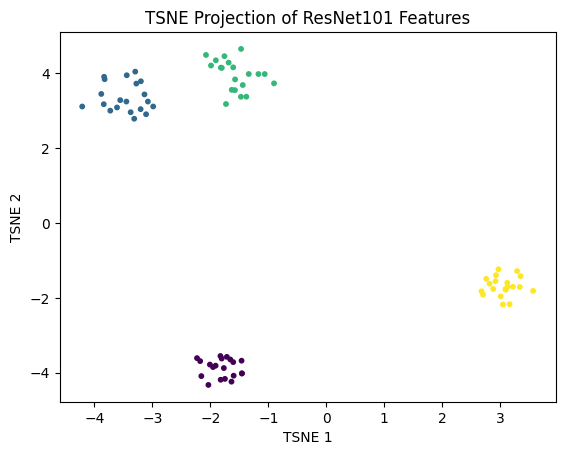

Louvain modularity: 0.7374


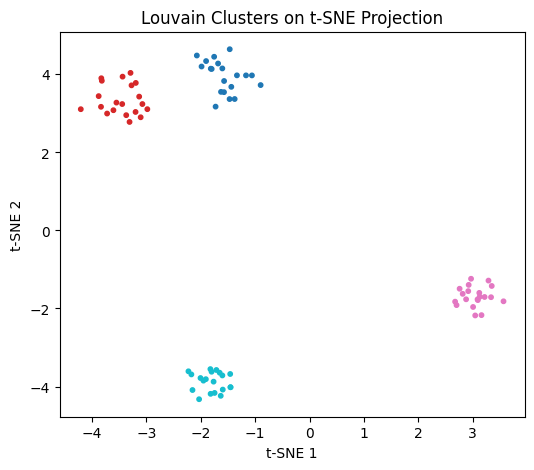

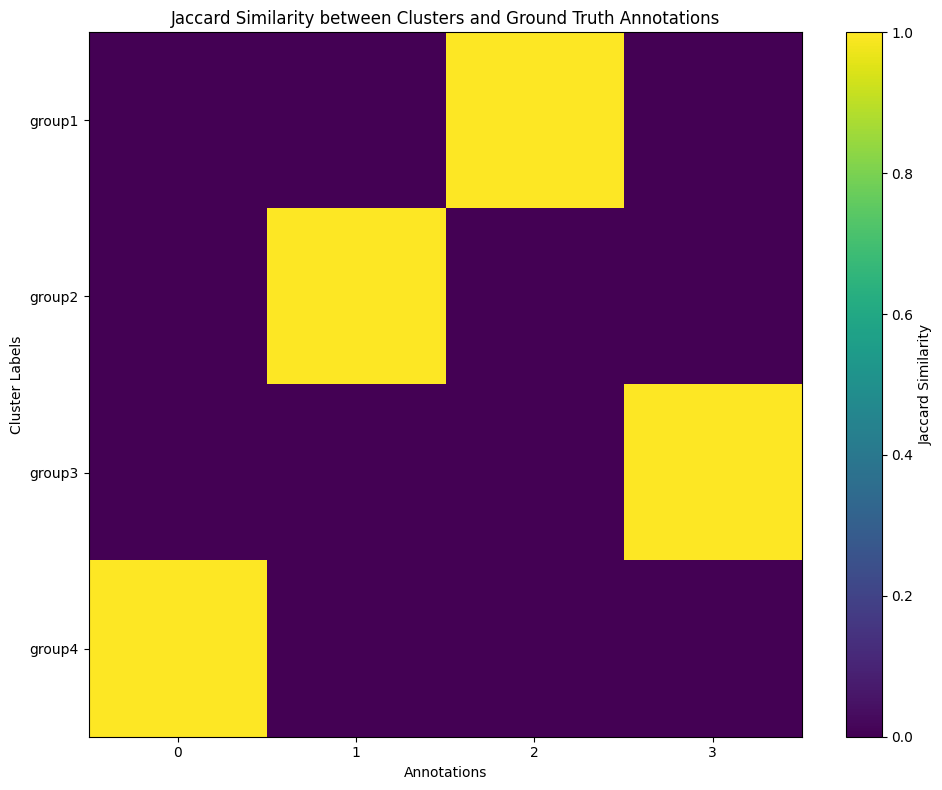

In [9]:
# Perform PCA
pca = PCA(n_components=30, random_state=42)
pca.fit(cell_features)
pcs_cell_features = pca.transform(cell_features)

plt.scatter(pcs_cell_features[:, 0], pcs_cell_features[:, 1], c=colors, marker='o', s=10)
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

#t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs_cell_features)

plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, marker='o', s=10)
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.show()

# Set random seed for reproducibility
seed = 42
np.random.seed(seed)

# Construct a k-Nearest Neighbors graph (using cosine distance)
knn_graph = kneighbors_graph(
    pcs_cell_features,         
    n_neighbors=15,
    metric='cosine',
    mode='connectivity',
    include_self=True
)

# Convert sparse matrix to a NetworkX graph
G = nx.from_scipy_sparse_array(knn_graph)

# Perform Louvain clustering
partition = cl.best_partition(G)

# Convert dictionary to cluster labels
clusters = np.array([partition[i] for i in range(len(pcs_cell_features))])

# Compute modularity (optional, but useful to assess clustering quality)
modularity_score = cl.modularity(partition, G)
print(f"Louvain modularity: {modularity_score:.4f}")

# Plot clusters on t-SNE projection
plt.figure(figsize=(6, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], c=clusters, cmap='tab10', s=10)
plt.title('Louvain Clusters on t-SNE Projection')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

# calculate jaccard similarity between clusters and ground truth labels
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(clusters, labels)

# plot jaccard similarity matrix
plt.figure(figsize=(10, 8))
plt.imshow(jaccard_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Jaccard Similarity')
plt.xticks(range(len(labels1)), labels1)
plt.yticks(range(len(labels2)), labels2)
plt.xlabel('Annotations')
plt.ylabel('Cluster Labels')
plt.title('Jaccard Similarity between Clusters and Ground Truth Annotations')
plt.tight_layout()


To weight features, we take the original count matrix and min-max scale the data based on genes. Then, we multiply the scaled gene expression to the extracted features from the deep learning model (Resnet).

In [10]:
# make numpy array from counts matrix
counts_matrix_np = counts_matrix[["gene1", "gene2", "gene3"]].to_numpy()


# get scaler
scaler = MinMaxScaler()
# scales each gene (column) to [0, 1]
counts_matrix_np_scaled = scaler.fit_transform(counts_matrix_np)
# check shape
print(counts_matrix_np_scaled.shape)

# Reshape feat into 3 chunks of 2048 features
feat_reshaped = cell_features.reshape(80, 3, 2048)  # shape (80, 3, 2048)

# Multiply each chunk by the corresponding value in counts_matrix_np_scaled
# Broadcasting automatically expands counts_matrix_np_scaled along the last dimension
weighted_cell_features = feat_reshaped * counts_matrix_np_scaled[:, :, np.newaxis]  # shape (80, 3, 2048)

# Flatten back to original feature dimension if desired
weighted_cell_features = weighted_cell_features.reshape(80, 6144)

(80, 3)


Doing the same analysis as above (before feature weighting) we now get distinct clusters that correspond to the ground truth labels.

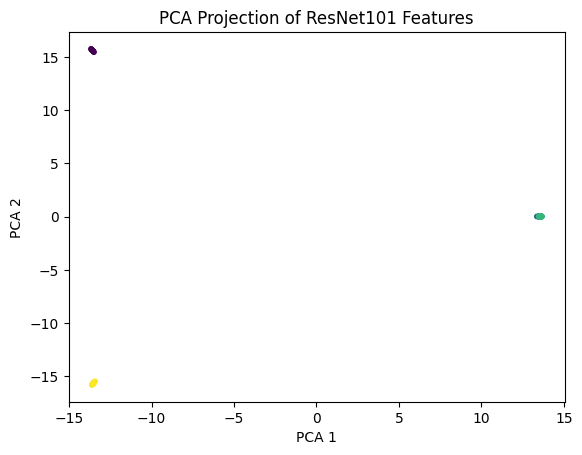

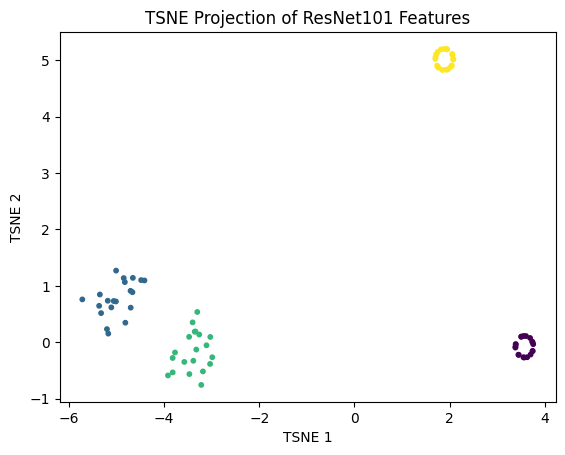

Louvain modularity: 0.7499


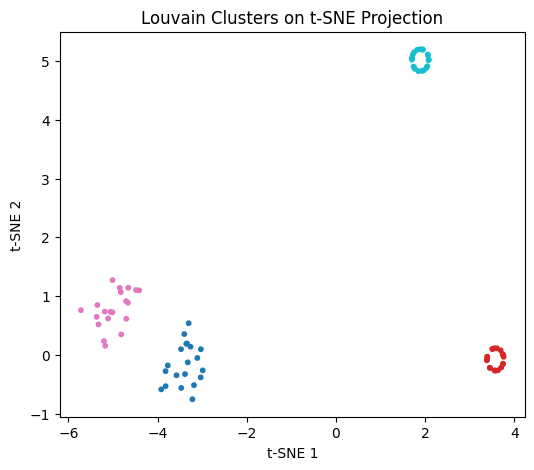

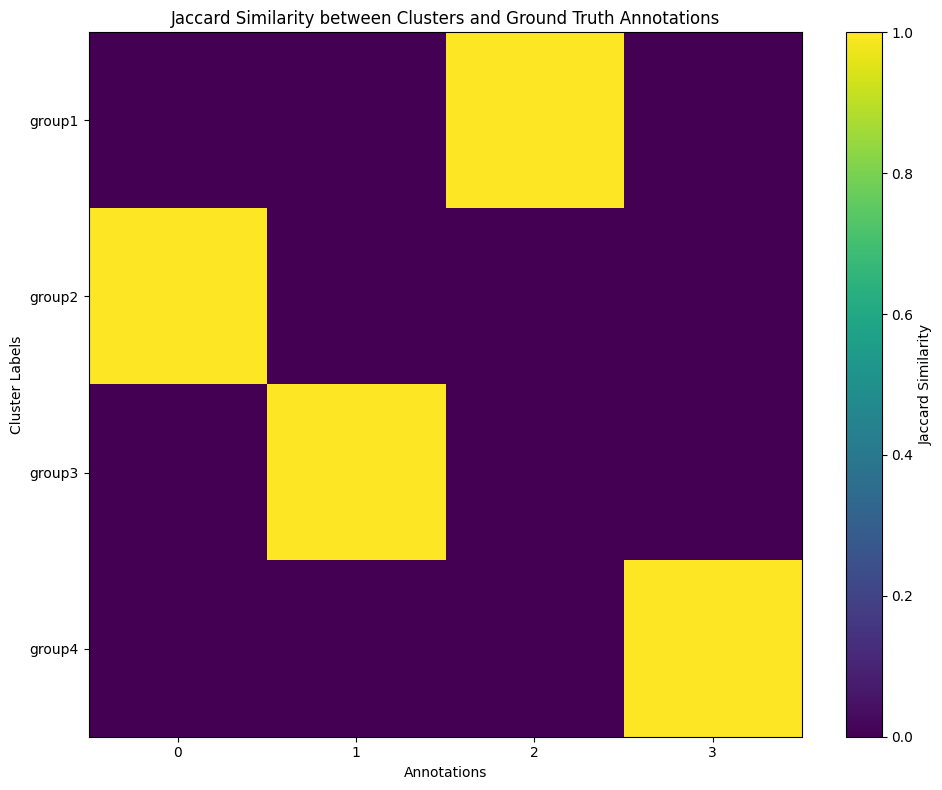

In [11]:
# Perform PCA
pca_weighted = PCA(n_components=30, random_state=42)
pca_weighted.fit(weighted_cell_features)
pcs_cell_features_weighted = pca_weighted.transform(weighted_cell_features)

plt.scatter(pcs_cell_features_weighted[:, 0], pcs_cell_features_weighted[:, 1], c=colors, marker='o', s=10)
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

#t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs_cell_features_weighted)

plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, marker='o', s=10)
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.show()

# Set random seed for reproducibility
seed = 42
np.random.seed(seed)

# Construct a k-Nearest Neighbors graph (using cosine distance)
knn_graph = kneighbors_graph(
    pcs_cell_features_weighted,         
    n_neighbors=10,
    metric='cosine',
    mode='connectivity',
    include_self=True
)

# Convert sparse matrix to a NetworkX graph
G = nx.from_scipy_sparse_array(knn_graph)

# Perform Louvain clustering
partition = cl.best_partition(G)

# Convert dictionary to cluster labels
clusters_weighted = np.array([partition[i] for i in range(len(pcs_cell_features_weighted))])

# Compute modularity (optional, but useful to assess clustering quality)
modularity_score = cl.modularity(partition, G)
print(f"Louvain modularity: {modularity_score:.4f}")

# Plot clusters on t-SNE projection
plt.figure(figsize=(6, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], c=clusters_weighted, cmap='tab10', s=10)
plt.title('Louvain Clusters on t-SNE Projection')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

# calculate jaccard similarity between clusters and ground truth labels
jaccard_matrix_weighted, labels1, labels2 = calculate_jaccard_similarity(clusters_weighted, labels)

# plot jaccard similarity matrix
plt.figure(figsize=(10, 8))
plt.imshow(jaccard_matrix_weighted, cmap='viridis', aspect='auto')
plt.colorbar(label='Jaccard Similarity')
plt.xticks(range(len(labels1)), labels1)
plt.yticks(range(len(labels2)), labels2)
plt.xlabel('Annotations')
plt.ylabel('Cluster Labels')
plt.title('Jaccard Similarity between Clusters and Ground Truth Annotations')
plt.tight_layout()


To demonstrate the advantage of using STARIT images for downstream analysis, we can apply the same analysis pipeline to the original counts matrix. In this case, we observe three distinct clusters, which is expected since groups 2 and 3 share similar overall transcript profiles but differ in the spatial localization of those transcripts within the cell (nuclear vs. peri-nuclear).

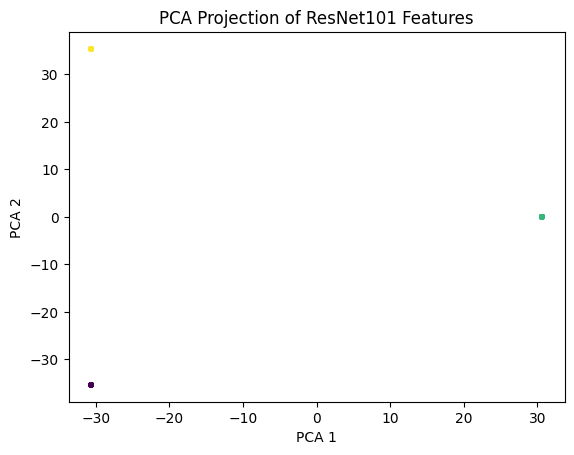

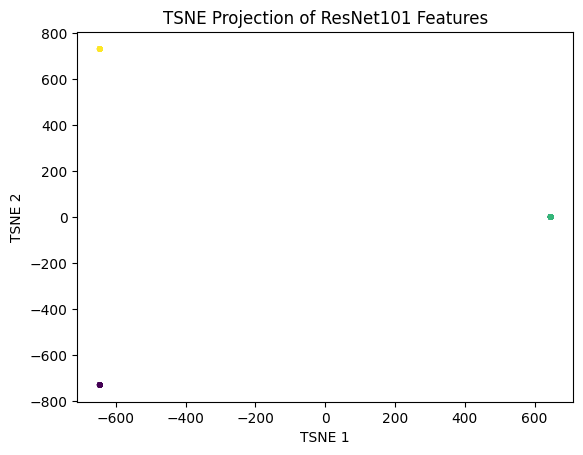

Louvain modularity: 0.5901


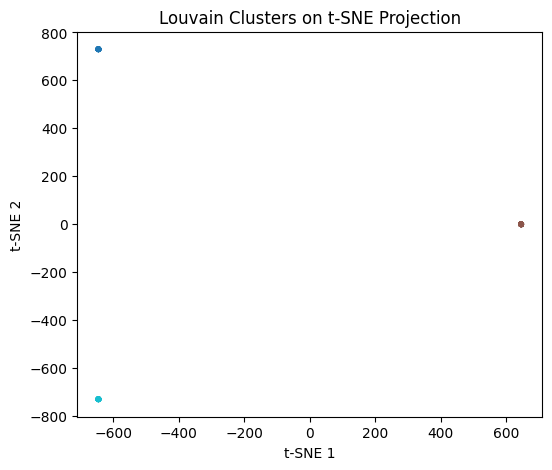

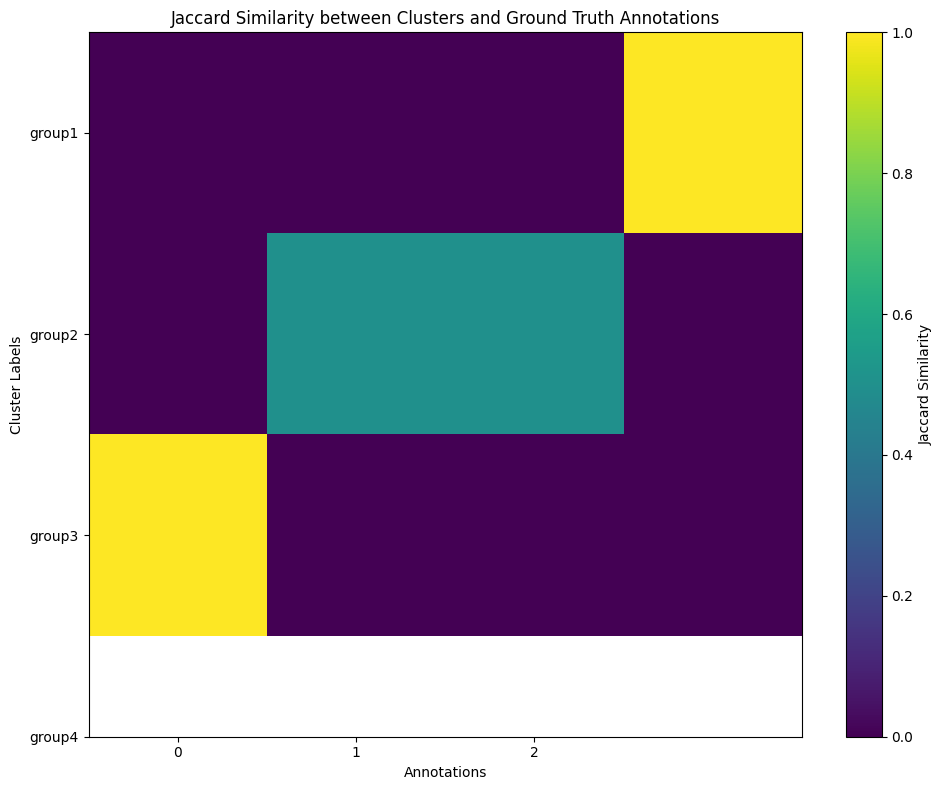

In [12]:
# run PCA on counts matrix
pca_traditional = PCA(n_components=2, random_state=42)
pca_traditional.fit(counts_matrix_np)
pcs_traditional = pca_traditional.transform(counts_matrix_np)

plt.scatter(pcs_traditional[:, 0], pcs_traditional[:, 1], c=colors, marker='o', s=10)
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

#t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
embedding_traditional = tsne.fit_transform(pcs_traditional)

plt.scatter(embedding_traditional[:, 0], embedding_traditional[:, 1], c=colors, marker='o', s=10)
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.show()


# Set random seed for reproducibility
seed = 42
np.random.seed(seed)

# Construct a k-Nearest Neighbors graph (using cosine distance)
knn_graph = kneighbors_graph(
    pcs_traditional,         
    n_neighbors=15,
    metric='cosine',
    mode='connectivity',
    include_self=True
)

# Convert sparse matrix to a NetworkX graph
G = nx.from_scipy_sparse_array(knn_graph)

# Perform Louvain clustering
partition = cl.best_partition(G)

# Convert dictionary to cluster labels
clusters_traditional = np.array([partition[i] for i in range(len(pcs_traditional))])

# Compute modularity (optional, but useful to assess clustering quality)
modularity_score = cl.modularity(partition, G)
print(f"Louvain modularity: {modularity_score:.4f}")

# Plot clusters on t-SNE projection
plt.figure(figsize=(6, 5))
plt.scatter(embedding_traditional[:, 0], embedding_traditional[:, 1], c=clusters_traditional, cmap='tab10', s=10)
plt.title('Louvain Clusters on t-SNE Projection')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

# calculate jaccard similarity between clusters and ground truth labels
jaccard_matrix_traditional, labels1, labels2 = calculate_jaccard_similarity(clusters_traditional, labels)

# plot jaccard similarity matrix
plt.figure(figsize=(10, 8))
plt.imshow(jaccard_matrix_traditional, cmap='viridis', aspect='auto')
plt.colorbar(label='Jaccard Similarity')
plt.xticks(range(len(labels1)), labels1)
plt.yticks(range(len(labels2)), labels2)
plt.xlabel('Annotations')
plt.ylabel('Cluster Labels')
plt.title('Jaccard Similarity between Clusters and Ground Truth Annotations')
plt.tight_layout()

